# **1. Perkenalan Dataset**

Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, roc_auc_score, ConfusionMatrixDisplay)
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [21]:
df = pd.read_csv("../Global_Superstore.csv")

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [4]:
# Informasi umum dataset
print("=== Info Dataset ===")
df.info()


=== Info Dataset ===
<class 'pandas.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 27 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Category        51290 non-null  str    
 1   City            51290 non-null  str    
 2   Country         51290 non-null  str    
 3   Customer ID     51290 non-null  str    
 4   Customer Name   51290 non-null  str    
 5   Discount        51290 non-null  float64
 6   Market          51290 non-null  str    
 7   ji_lu-shu       51290 non-null  int64  
 8   Order Date      51290 non-null  str    
 9   Order ID        51290 non-null  str    
 10  Order Priority  51290 non-null  str    
 11  Product ID      51290 non-null  str    
 12  Product Name    51290 non-null  str    
 13  Profit          51290 non-null  float64
 14  Quantity        51290 non-null  int64  
 15  Region          51290 non-null  str    
 16  Row ID          51290 non-null  int64  
 17  Sales           51290

In [5]:
print("\n=== Statistik Deskriptif ===")
df.describe()


=== Statistik Deskriptif ===


,Discount,ji_lu-shu,Profit,Quantity,Row ID,Sales,Shipping Cost,Year,weeknum
count,51290.000000,51290.0,51290.000000,51290.000000,51290.00000,51290.000000,51290.000000,51290.000000,51290.000000
mean,0.142908,1.0,28.610982,3.476545,25645.50000,246.498440,26.375818,2012.777208,31.287112
std,0.212280,0.0,174.340972,2.278766,14806.29199,487.567175,57.296810,1.098931,14.429795
min,0.000000,1.0,-6599.978000,1.000000,1.00000,0.000000,0.002000,2011.000000,1.000000
25%,0.000000,1.0,0.000000,2.000000,12823.25000,31.000000,2.610000,2012.000000,20.000000
50%,0.000000,1.0,9.240000,3.000000,25645.50000,85.000000,7.790000,2013.000000,33.000000
75%,0.200000,1.0,36.810000,5.000000,38467.75000,251.000000,24.450000,2014.000000,44.000000
max,0.850000,1.0,8399.976000,14.000000,51290.00000,22638.000000,933.570000,2014.000000,53.000000


In [6]:
# Missing values
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing'] > 0])


Empty DataFrame
Columns: [Missing, Percentage]
Index: []


In [7]:
# Duplikasi
print(f"Jumlah baris duplikat: {df.duplicated().sum()}")


Jumlah baris duplikat: 0


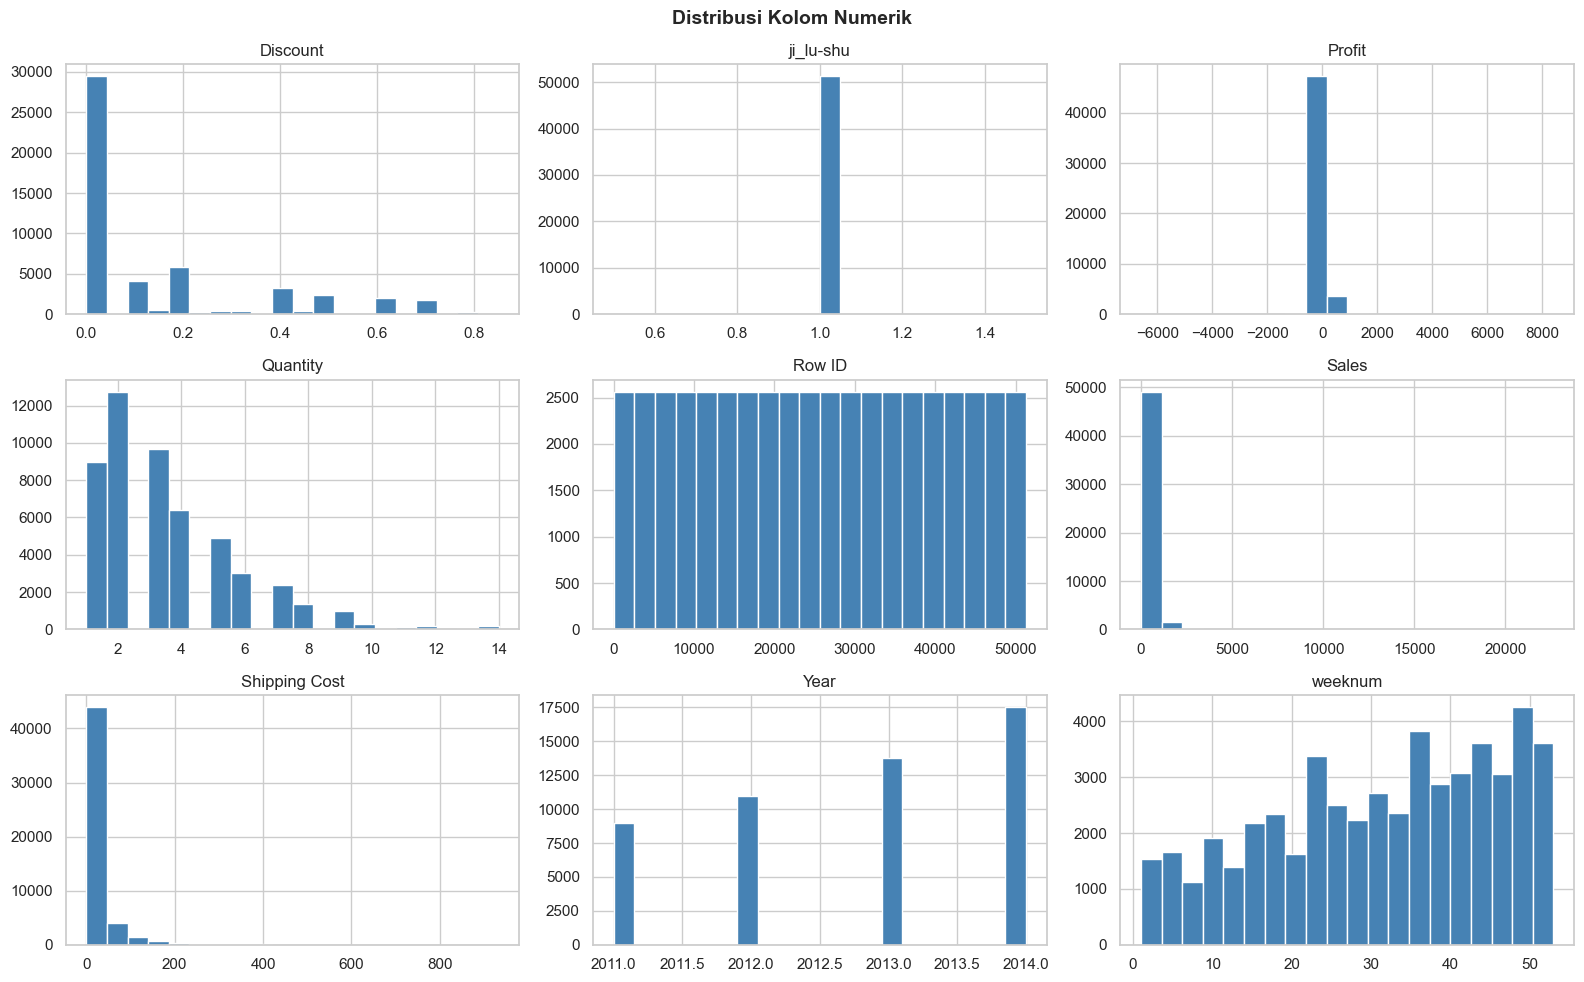

In [8]:
# Distribusi kolom numerik
num_cols = df.select_dtypes(include=np.number).columns.tolist()
df[num_cols].hist(bins=20, figsize=(16, 10), color='steelblue', edgecolor='white')
plt.suptitle('Distribusi Kolom Numerik', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


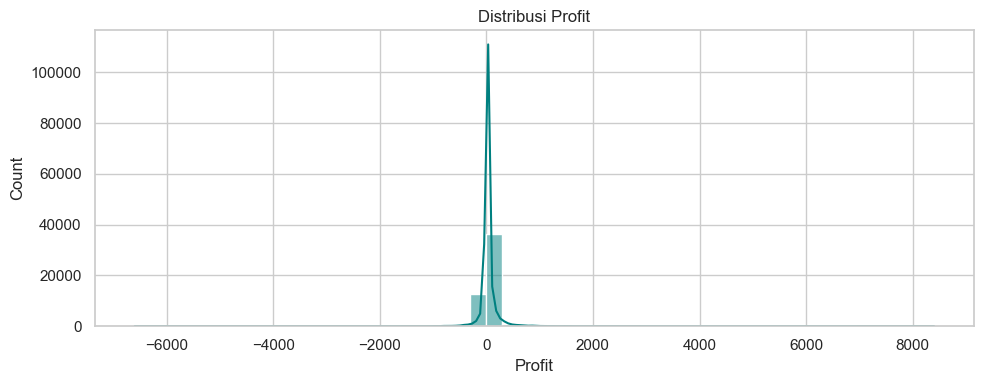

Profit min: -6599.98
Profit max: 8399.98
Transaksi rugi (Profit < 0): 12544 (24.5%)
Transaksi untung (Profit >= 0): 38746 (75.5%)


In [9]:
# Distribusi target: Profit
plt.figure(figsize=(10, 4))
sns.histplot(df['Profit'], bins=50, kde=True, color='teal')
plt.title('Distribusi Profit')
plt.xlabel('Profit')
plt.tight_layout()
plt.show()

print(f"Profit min: {df['Profit'].min():.2f}")
print(f"Profit max: {df['Profit'].max():.2f}")
print(f"Transaksi rugi (Profit < 0): {(df['Profit'] < 0).sum()} ({(df['Profit'] < 0).mean()*100:.1f}%)")
print(f"Transaksi untung (Profit >= 0): {(df['Profit'] >= 0).sum()} ({(df['Profit'] >= 0).mean()*100:.1f}%)")


Kolom kategorikal: ['Category', 'City', 'Country', 'Customer ID', 'Customer Name', 'Market', 'Order Date', 'Order ID', 'Order Priority', 'Product ID', 'Product Name', 'Region', 'Segment', 'Ship Date', 'Ship Mode', 'State', 'Sub-Category', 'Market2']


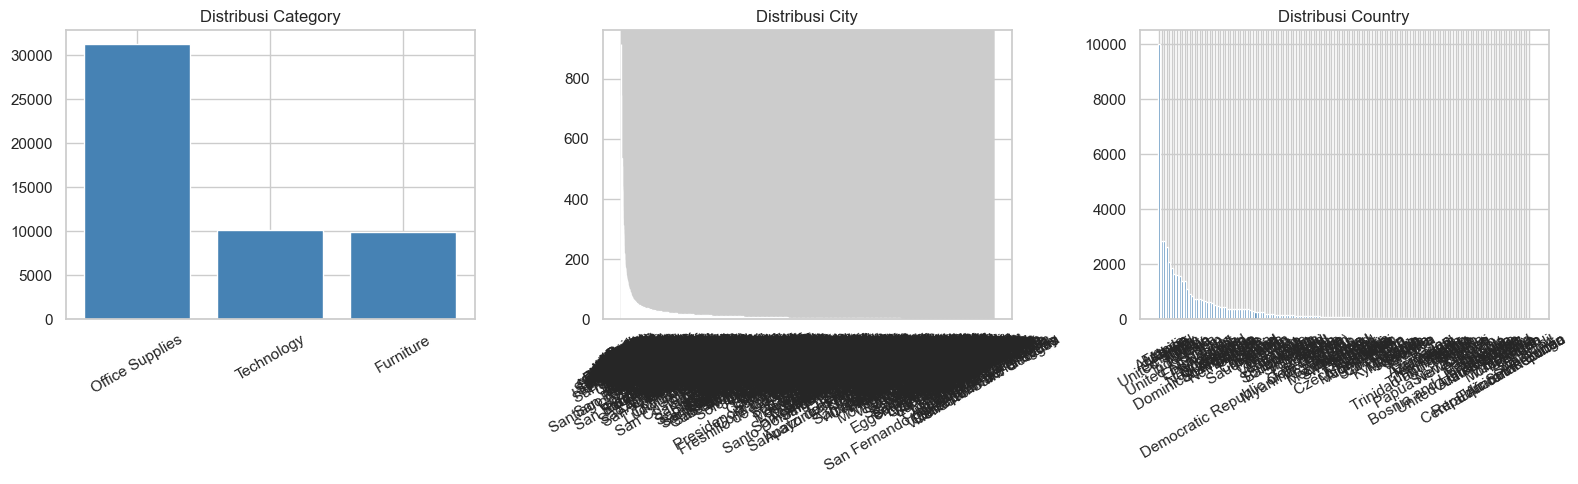

In [10]:
# Distribusi kategorikal
cat_cols = df.select_dtypes(include='object').columns.tolist()
print("Kolom kategorikal:", cat_cols)

fig, axes = plt.subplots(1, min(3, len(cat_cols)), figsize=(16, 5))
for i, col in enumerate(cat_cols[:3]):
    vc = df[col].value_counts()
    axes[i].bar(vc.index, vc.values, color='steelblue', edgecolor='white')
    axes[i].set_title(f'Distribusi {col}')
    axes[i].tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


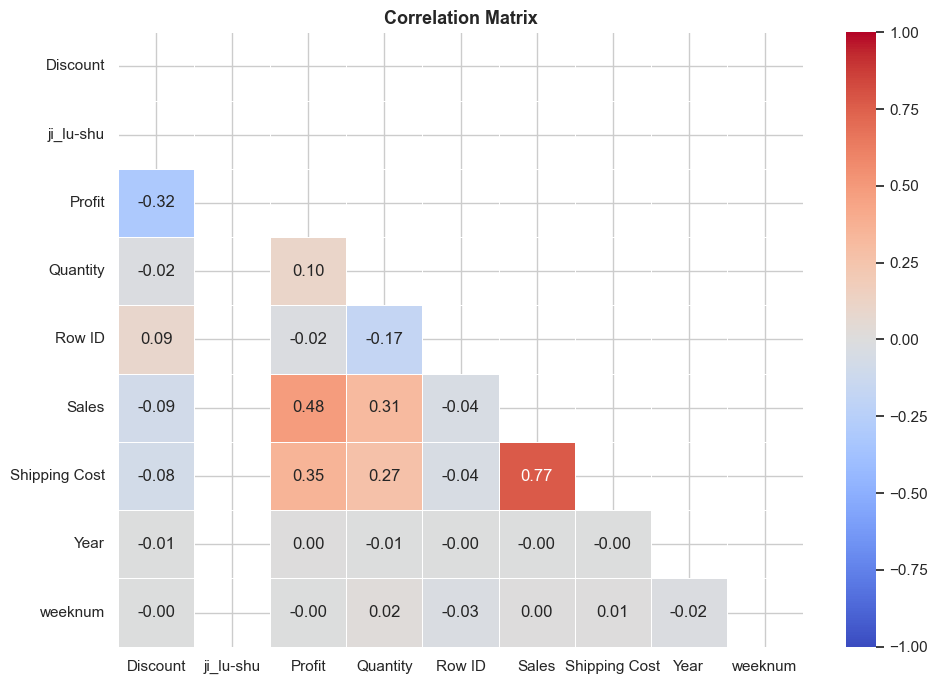

In [11]:
# Korelasi antar fitur numerik
plt.figure(figsize=(10, 7))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1)
plt.title('Correlation Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


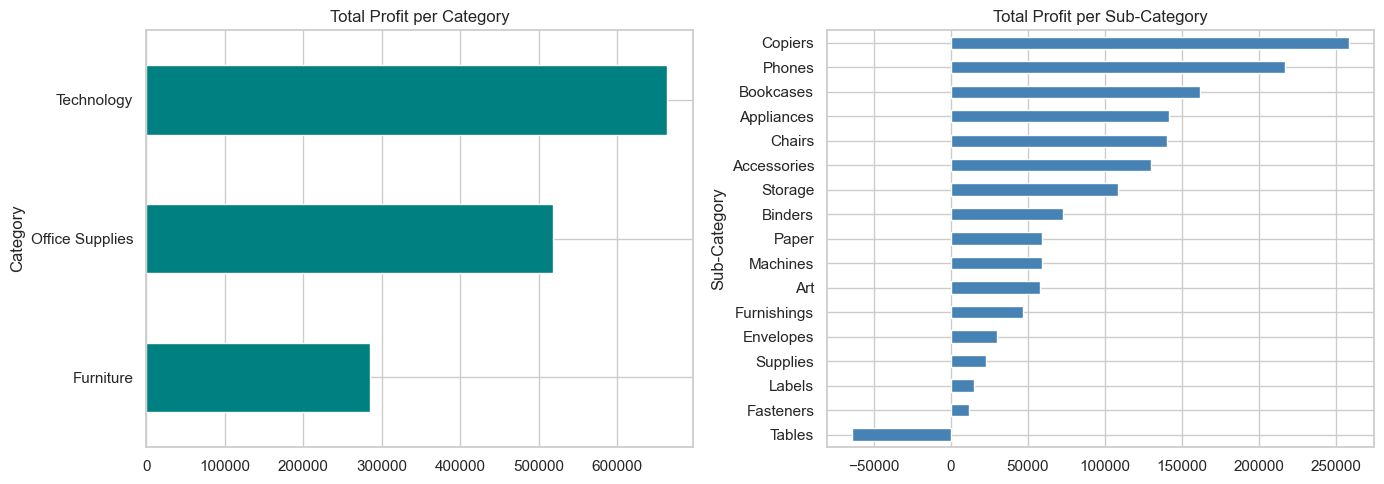

In [12]:
# Profit per Category & Sub-Category
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
df.groupby('Category')['Profit'].sum().sort_values().plot(kind='barh', ax=axes[0], color='teal')
axes[0].set_title('Total Profit per Category')

df.groupby('Sub-Category')['Profit'].sum().sort_values().plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Total Profit per Sub-Category')
plt.tight_layout()
plt.show()


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [13]:
# Salin dataset asli
df_clean = df.copy()

# Hapus kolom ID yang tidak relevan untuk model
id_cols = [c for c in df_clean.columns if 'id' in c.lower() or 'name' in c.lower()
           or 'postal' in c.lower() or 'date' in c.lower() or 'city' in c.lower()
           or 'state' in c.lower() or 'country' in c.lower() or 'region' in c.lower()]
print("Kolom yang akan dihapus:", id_cols)
df_clean.drop(columns=id_cols, inplace=True, errors='ignore')
df_clean.shape


Kolom yang akan dihapus: ['City', 'Country', 'Customer ID', 'Customer Name', 'Order Date', 'Order ID', 'Product ID', 'Product Name', 'Region', 'Row ID', 'Ship Date', 'State']


(51290, 15)

In [14]:
# Buat kolom target biner: Profitable (1 jika Profit >= 0, 0 jika tidak)
df_clean['Profitable'] = (df_clean['Profit'] >= 0).astype(int)
print(df_clean['Profitable'].value_counts())
print(f"Rasio kelas: {df_clean['Profitable'].mean():.2%} positif")


Profitable
1    38746
0    12544
Name: count, dtype: int64
Rasio kelas: 75.54% positif


In [15]:
# Hapus baris duplikat
before = len(df_clean)
df_clean.drop_duplicates(inplace=True)
print(f"Baris dihapus (duplikat): {before - len(df_clean)}")


Baris dihapus (duplikat): 0


In [16]:
# Tangani missing values
imputer_num = SimpleImputer(strategy='median')
imputer_cat = SimpleImputer(strategy='most_frequent')

num_feats = df_clean.select_dtypes(include=np.number).columns.tolist()
cat_feats = df_clean.select_dtypes(include='object').columns.tolist()

df_clean[num_feats] = imputer_num.fit_transform(df_clean[num_feats])
df_clean[cat_feats] = imputer_cat.fit_transform(df_clean[cat_feats])
print("Missing values setelah imputasi:", df_clean.isnull().sum().sum())


Missing values setelah imputasi: 0


In [17]:
# Encoding kolom kategorikal
le = LabelEncoder()
for col in cat_feats:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
df_clean.head()


,Category,Discount,Market,ji_lu-shu,Order Priority,Profit,Quantity,Sales,Segment,Ship Mode,Shipping Cost,Sub-Category,Year,Market2,weeknum,Profitable
0,1,0.0,6,1.0,1,9.3312,3.0,19.0,0,2,4.37,12,2011.0,5,2.0,1.0
1,1,0.0,6,1.0,3,9.2928,2.0,19.0,0,3,0.94,12,2011.0,5,4.0,1.0
2,1,0.0,6,1.0,3,9.8418,3.0,21.0,0,3,1.81,12,2011.0,5,32.0,1.0
3,1,0.0,6,1.0,3,53.2608,2.0,111.0,0,3,4.59,12,2011.0,5,32.0,1.0
4,1,0.0,6,1.0,1,3.1104,1.0,6.0,0,3,1.32,12,2011.0,5,40.0,1.0


In [18]:
# Deteksi & penanganan outlier pada kolom numerik utama menggunakan IQR clipping
cols_to_clip = ['Sales', 'Discount', 'Quantity']
cols_to_clip = [c for c in cols_to_clip if c in df_clean.columns]

for col in cols_to_clip:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower, upper = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    before_out = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    df_clean[col] = df_clean[col].clip(lower, upper)
    print(f"{col}: {before_out} outlier di-clip ke [{lower:.2f}, {upper:.2f}]")


Sales: 5655 outlier di-clip ke [-299.00, 581.00]
Discount: 4172 outlier di-clip ke [-0.30, 0.50]
Quantity: 877 outlier di-clip ke [-2.50, 9.50]


In [19]:
# Split fitur & target
feature_cols = [c for c in df_clean.columns if c not in ['Profit', 'Profitable']]
X = df_clean[feature_cols]
y = df_clean['Profitable']

# Normalisasi fitur numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=feature_cols)

# Train-test split (80:20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print(f"y_train distribusi:\n{y_train.value_counts()}")
print(f"y_test distribusi:\n{y_test.value_counts()}")


X_train: (41032, 14), X_test: (10258, 14)
y_train distribusi:
Profitable
1.0    30997
0.0    10035
Name: count, dtype: int64
y_test distribusi:
Profitable
1.0    7749
0.0    2509
Name: count, dtype: int64


In [20]:
print("=== Data siap untuk pemodelan ===")
print(f"Jumlah fitur : {X_train.shape[1]}")
print(f"Jumlah data latih : {len(X_train)}")
print(f"Jumlah data uji : {len(X_test)}")


=== Data siap untuk pemodelan ===
Jumlah fitur : 14
Jumlah data latih : 41032
Jumlah data uji : 10258
